# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Two trials are recorded. Best is trial_01 (sw 0.409, h_s 3.354, h_f 1.837, cap 0.156) at objective 0.1243 (0 diverged, gamma finite on all 8; mu rel-RMSE 58.1%, gamma rel-RMSE 27.3%). trial_02 (sw 0.884, h_f 0.642, h_s 1.007, cap 0.054) was worse at 0.1287 (0 diverged; mu rel-RMSE 95.9% from a large low-T overshoot, gamma rel-RMSE 17.0%). Both sit above the experiment_5 honest level (~0.108-0.113). The campaign is still in the uniform phase (2/5 completed), so the candidates below are independent random draws.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"gamma_rel_cap": 0.04282458357181218, "h_f_scale": 1.138039399735374, "h_s_scale": 3.2547792445239883, "sigma_weight": 0.5821620360643678}
 2 |      - | {"gamma_rel_cap": 0.04706432112019959, "h_f_scale": 1.8742260258867767, "h_s_scale": 2.046442368028128, "sigma_weight": 0.15973891463707857}
 3 |      - | {"gamma_rel_cap": 0.36728857570460727, "h_f_scale": 0.6762700747052628, "h_s_scale": 1.7171057143587327, "sigma_weight": 0.5167401826213637}
 4 |      - | {"gamma_rel_cap": 0.2153140102070889, "h_f_scale": 2.4504946428930277, "h_s_scale": 3.0168917023456006, "sigma_weight": 0.9562672548360985}
 5 |      - | {"gamma_rel_cap": 0.14210058187439573, "h_f_scale": 2.6820520265493437, "h_s_scale": 2.860809987513083, "sigma_weight": 0.2927207490124871}
 6 |      - | {"gamma_rel_cap": 0.0007450417544180854, "h_f_scale": 3.9004760303740476, "h_s_scale": 1.3690045863132838, "sigma_weight": 0.3139860020343368}
 7 |      - | {"gamm

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Registry: trial_01 (sw 0.409, h_s 3.354, h_f 1.837, cap 0.156) is best at 0.1243; trial_02 (sw 0.884, h_f 0.642, h_s 1.007, cap 0.054) is worse at 0.1287. When compared, trial_01's better mu error came together with a flat sigma kernel (h_s 3.35) and a looser FWHM kernel (h_f 1.84), whereas trial_02 used nominal h_s and a sharp h_f 0.64; the sigma weight itself differed in the opposite direction (0.41 vs 0.88), so sw and the bandwidths are entangled in these two points. Uniform phase (2/5): all candidates are random draws with ei = '-'.

The most informative next draw is a new combination that keeps the two features shared by the better trial_01 (flat sigma kernel, looser FWHM kernel) but restores the sigma weight to near-maximal, to test whether the mu gain came from the kernels rather than from damping the sigma channel away: candidate 4 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215). It separates sw from the bandwidths instead of moving them together, and the moderate gamma cap 0.215 guards the low-count gamma step.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # candidate 4: sigma_weight 0.956, h_f_scale 2.450, h_s_scale 3.017, gamma_rel_cap 0.215 (flat kernels, near-full sw)


chosen: {'gamma_rel_cap': 0.2153140102070889, 'h_f_scale': 2.4504946428930277, 'h_s_scale': 3.0168917023456006, 'sigma_weight': 0.9562672548360985}
Running  1nW Trans05 ... 

μ 9.39 -> 7.43 | γ 8.5 -> 5.68 | NLL 0.53


Running  1nW Trans20 ... 

μ 17.32 -> 34.28 | γ 8.5 -> 5.88 | NLL 1.23


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 68.92 | γ 14.1 -> 14.23 | NLL 1.19


Running 3nW Trans100 ... 

μ 175.71 -> 99.44 | γ 14.1 -> 13.89 | NLL 1.17



Total: 7.3 min


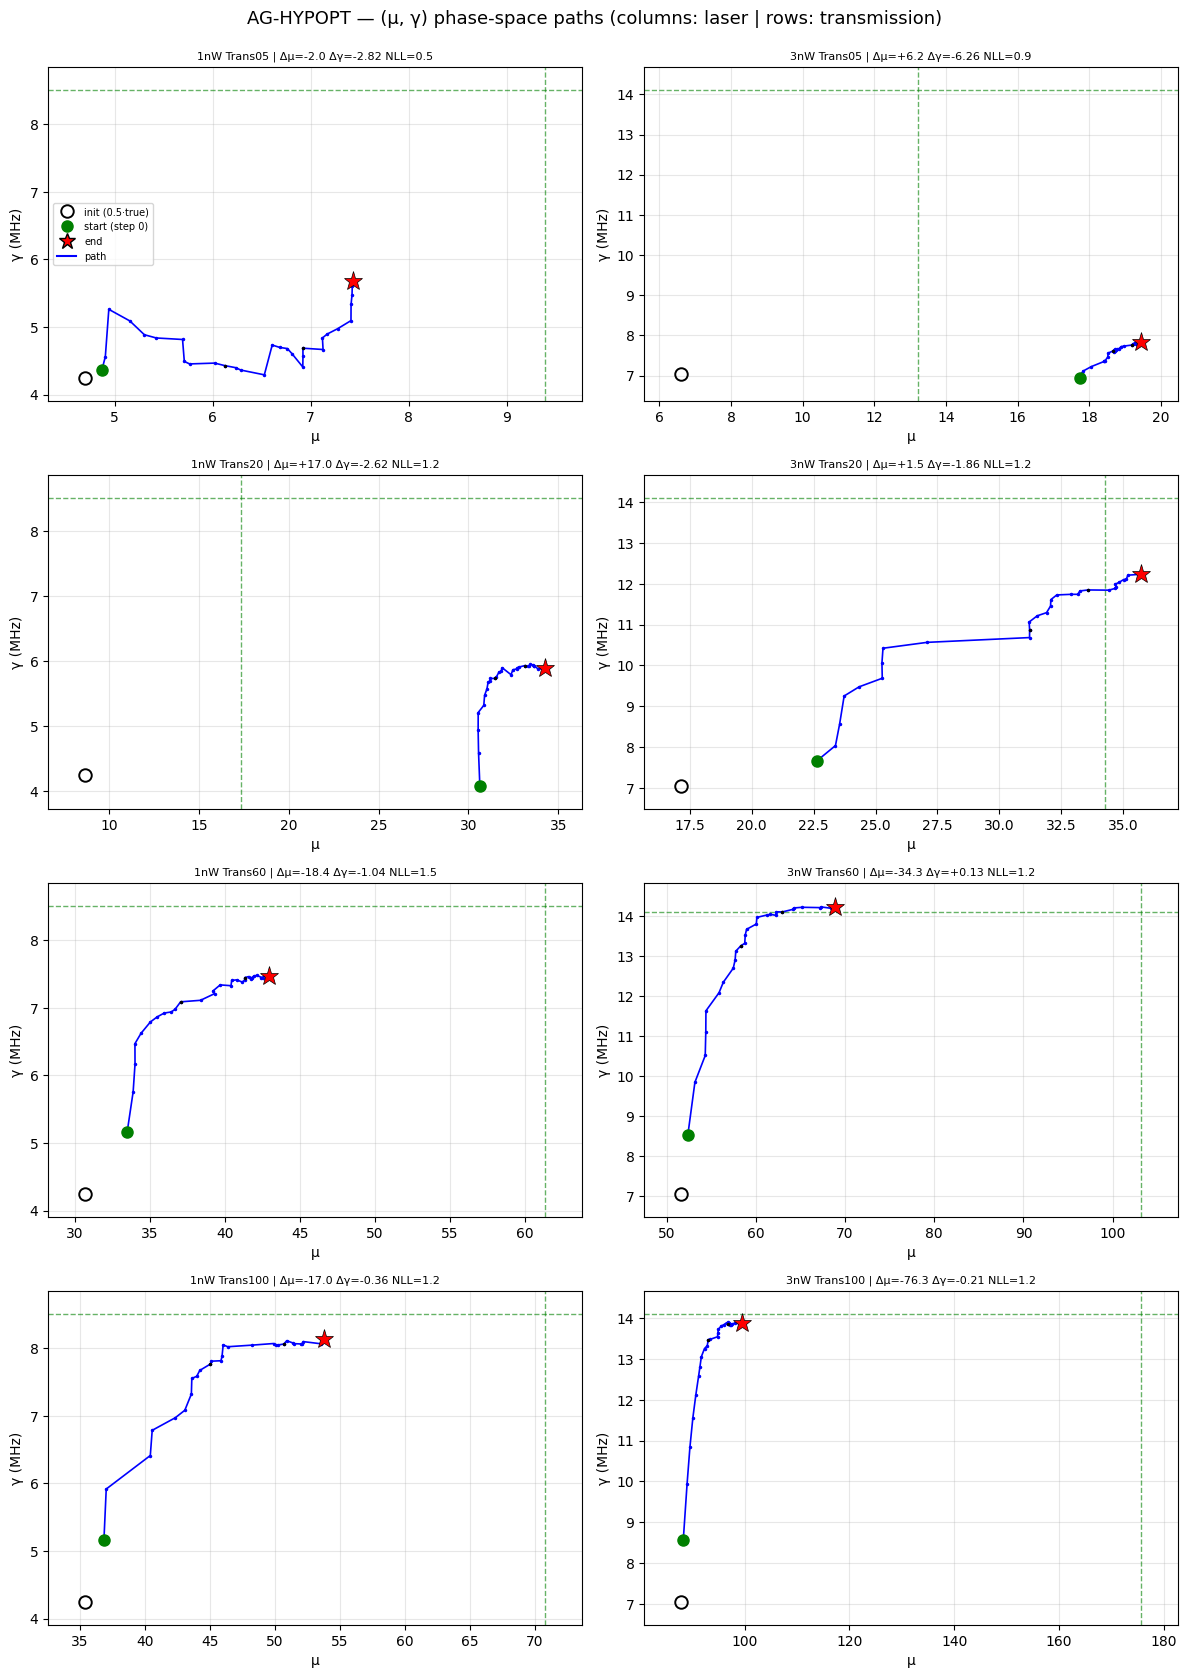

trial finished in 7.3 min
objective = 0.1040 ± 0.0582
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    7.43   -20.9 |     8.50    5.68   -33.2
1nW Trans20       17.32   34.28   +98.0 |     8.50    5.88   -30.8
1nW Trans60       61.37   42.96   -30.0 |     8.50    7.46   -12.2
1nW Trans100       70.82   53.82   -24.0 |     8.50    8.14    -4.2
3nW Trans05       13.20   19.45   +47.3 |    14.10    7.84   -44.4
3nW Trans20       34.28   35.73    +4.2 |    14.10   12.24   -13.2
3nW Trans60      103.20   68.92   -33.2 |    14.10   14.23    +0.9
3nW Trans100      175.71   99.44   -43.4 |    14.10   13.89    -1.5

weighted objective (T-graded, cap=1.0) = 0.1040 | diverged cells: 0
μ: RMSE 31.528 (rel 45.8%, bias -15.408) | γ: RMSE 2.708 (rel 23.3%, bias -1.879)


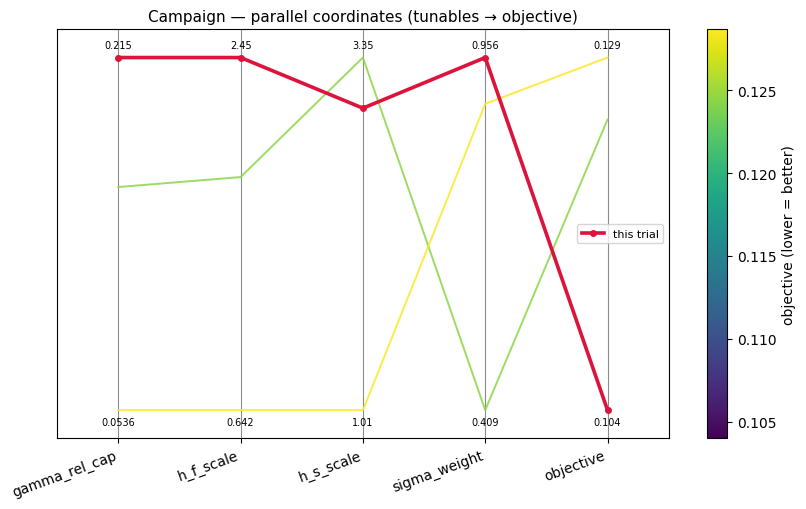

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) ran to completion in 7.3 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.1040 +/- 0.0582 - a new best, the first trial to beat both the experiment_5 honest level (~0.108-0.113) and the 0.1074 headline.

mu rel-RMSE improved to 45.8% (trial_01 58.1%, trial_02 95.9%), though the pattern is unchanged: strong undershoot at high T (3nW Trans100 -43.4%, 3nW Trans60 -33.2%, 1nW Trans60 -30.0%, 1nW Trans100 -24.0%) and overshoot at low T (1nW Trans20 +98.0%, 3nW Trans05 +47.3%); overall bias -15.41.

gamma rel-RMSE 23.3%: under-estimated at low T (-44.4%, 3nW Trans05; -33.2%, 1nW Trans05; -30.8%, 1nW Trans20; -13.2%, 3nW Trans20) and recovered at high T (+0.9%, -1.5%, -4.2%, -12.2%).

Relative to trial_01 this candidate kept both kernels flat (h_f 2.45, h_s 3.02, vs 1.84/3.35) but restored sigma_weight to 0.956 (vs 0.409), and the objective improved 0.1243 -> 0.1040; the sharp-FWHM near-default trial_02 (0.1287) sits on the other side, so the productive region so far is flat kernels with a strong sigma link.

**Summary:** Trial 03 (sw=0.956, h_f=2.450, h_s=3.017, cap=0.215) finished in 7.3 min with 0 diverged cells and gamma finite, objective 0.1040 +/- 0.0582 - a new best below the exp5 honest level and the 0.1074 headline (mu rel-RMSE 45.8%, gamma rel-RMSE 23.3%).
**Key insight:** Restoring near-full sigma weight (sw 0.96) while keeping both kernels flat (h_f 2.45, h_s 3.02) beats the exp5 level at 0.1040, indicating the flat-kernel score design rather than sigma damping carries the improvement.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 03 (sw=0.956, h_f=2.450, h_s=3.017, cap=0.215): objective 0.1040 +/- 0.0582 - new best, below the exp5 honest level and the 0.1074 headline; 0 diverged cells, gamma finite on all 8 (mu rel-RMSE 45.8%, gamma rel-RMSE 23.3%).'
KEY_INSIGHT = 'Restoring near-full sigma weight (sw 0.96) while keeping both kernels flat (h_f 2.45, h_s 3.02) beats the exp5 level at 0.1040, so the flat-kernel score design rather than sigma damping carries the improvement.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_03


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
